# GANA Embedding Dimension Sweep

**Goal:** Test whether GANA's geometric structure is genuinely meaningless, or just invisible at ed=2. Sweep ed in {2, 4, 8, 16} for full GANA + ablation and measure how spatial coherence scales with dimension.

**The decisive question:**
- If coherence Z-scores climb with ed and the gap between GANA and ablation widens, geometry is real but needs room. Thesis partially rescued.
- If Z-scores stay flat across all dimensions, the curvature term is not what organizes representations.

8 runs total, ~25 min on T4.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
import time, random, json

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


In [ ]:
class GANALayer(nn.Module):
    def __init__(self, in_dim, out_dim, embedding_dim, neighbor_radius=1.5, geom_weight=0.2):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.positions = nn.Parameter(torch.randn(out_dim, embedding_dim) * 0.5)
        self.neighbor_radius = neighbor_radius
        self.geom_weight = geom_weight

    def compute_curvature_modulation(self, activations):
        with torch.no_grad():
            dists = torch.cdist(self.positions, self.positions)
            mask = (dists < self.neighbor_radius) & (dists > 1e-6)
            inv_dist = torch.where(mask, 1.0 / (dists + 1e-6), torch.zeros_like(dists))
            row_sum = inv_dist.sum(dim=1, keepdim=True).clamp(min=1e-6)
            weights = inv_dist / row_sum
        local_mean = activations @ weights.t()
        curvature = activations - local_mean
        return activations - self.geom_weight * curvature

    def forward(self, x):
        a = self.linear(x)
        if self.geom_weight > 0:
            a = self.compute_curvature_modulation(a)
        return F.relu(a)

class GANAModel(nn.Module):
    def __init__(self, hidden_dims, num_classes=10, embedding_dim=2, neighbor_radius=1.5, geom_weight=0.2):
        super().__init__()
        layers = []
        in_dim = 28 * 28
        for h in hidden_dims:
            layers.append(GANALayer(in_dim, h, embedding_dim, neighbor_radius, geom_weight))
            in_dim = h
        self.hidden = nn.ModuleList(layers)
        self.classifier = nn.Linear(in_dim, num_classes)

    def forward(self, x, return_activations=False):
        x = x.view(x.size(0), -1)
        acts = []
        for layer in self.hidden:
            x = layer(x)
            acts.append(x)
        logits = self.classifier(x)
        if return_activations:
            return logits, acts
        return logits

In [ ]:
def train_model(model, epochs=10, lr=1e-3, label='model'):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    final_acc = 0.0
    for ep in range(epochs):
        model.train()
        running, n = 0.0, 0
        t0 = time.time()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward(); opt.step()
            running += loss.item() * x.size(0); n += x.size(0)
        sched.step()
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        final_acc = correct / total
        print(f'[{label}] ep {ep+1}/{epochs}  loss={running/n:.4f}  acc={final_acc:.4f}  ({time.time()-t0:.1f}s)')
    return final_acc

def collect_activations(model, loader):
    model.eval()
    all_a, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, acts = model(x, return_activations=True)
            all_a.append(acts[-1].cpu()); all_y.append(y)
    return torch.cat(all_a).numpy(), torch.cat(all_y).numpy()

def preferred_class(activations, labels, num_classes=10):
    num_neurons = activations.shape[1]
    avg = np.zeros((num_neurons, num_classes))
    for c in range(num_classes):
        m = labels == c
        if m.sum() > 0:
            avg[:, c] = activations[m].mean(axis=0)
    return avg.argmax(axis=1)

def spatial_coherence(positions, pref, k=5, n_shuffles=200):
    n = len(positions)
    k = min(k, n - 1)
    knn = NearestNeighbors(n_neighbors=k + 1).fit(positions)
    _, idx = knn.kneighbors(positions)
    idx = idx[:, 1:]
    real = (pref[idx] == pref[:, None]).mean()
    rng = np.random.default_rng(SEED)
    scores = []
    for _ in range(n_shuffles):
        sh = rng.permutation(pref)
        scores.append((sh[idx] == sh[:, None]).mean())
    shuffles = np.array(scores)
    z = (real - shuffles.mean()) / (shuffles.std() + 1e-8)
    return float(real), float(shuffles.mean()), float(shuffles.std()), float(z)

In [ ]:
EMBEDDING_DIMS = [2, 4, 8, 16]
EPOCHS = 10
HIDDEN = [256, 128]
results = {}

for ed in EMBEDDING_DIMS:
    for variant, gw in [('gana', 0.2), ('gana_abl', 0.0)]:
        name = f'ed{ed}_{variant}'
        print(f'\n=== {name} ===')
        torch.manual_seed(SEED)
        model = GANAModel(HIDDEN, embedding_dim=ed, neighbor_radius=1.5, geom_weight=gw)
        acc = train_model(model, epochs=EPOCHS, label=name)
        activations, labels = collect_activations(model, test_loader)
        pref = preferred_class(activations, labels)
        pos = model.hidden[-1].positions.detach().cpu().numpy()
        coh, sm, ss, z = spatial_coherence(pos, pref, k=5)
        results[name] = {'ed': ed, 'variant': variant, 'acc': acc,
                          'coherence': coh, 'shuffle_mean': sm, 'shuffle_std': ss, 'z_score': z}
        print(f'  -> acc={acc:.4f}  coherence={coh:.4f}  Z={z:.2f}')

print('\n=== Summary table ===')
print(f'{"ed":>4} {"variant":>10} {"acc":>8} {"coherence":>11} {"Z-score":>9}')
for name, r in results.items():
    print(f'{r["ed"]:>4} {r["variant"]:>10} {r["acc"]:>8.4f} {r["coherence"]:>11.4f} {r["z_score"]:>9.2f}')


=== ed2_gana ===
[ed2_gana] ep 1/10  loss=0.2940  acc=0.9596  (18.9s)
[ed2_gana] ep 2/10  loss=0.1104  acc=0.9715  (16.5s)
[ed2_gana] ep 3/10  loss=0.0723  acc=0.9712  (16.4s)
[ed2_gana] ep 4/10  loss=0.0484  acc=0.9767  (16.2s)
[ed2_gana] ep 5/10  loss=0.0346  acc=0.9788  (18.9s)
[ed2_gana] ep 6/10  loss=0.0218  acc=0.9797  (16.0s)
[ed2_gana] ep 7/10  loss=0.0136  acc=0.9809  (16.3s)
[ed2_gana] ep 8/10  loss=0.0087  acc=0.9820  (16.2s)
[ed2_gana] ep 9/10  loss=0.0063  acc=0.9821  (16.9s)
[ed2_gana] ep 10/10  loss=0.0051  acc=0.9822  (16.7s)
  -> acc=0.9822  coherence=0.1297  Z=1.41

=== ed2_gana_abl ===
[ed2_gana_abl] ep 1/10  loss=0.2703  acc=0.9633  (15.7s)
[ed2_gana_abl] ep 2/10  loss=0.1020  acc=0.9715  (15.3s)
[ed2_gana_abl] ep 3/10  loss=0.0681  acc=0.9731  (15.3s)
[ed2_gana_abl] ep 4/10  loss=0.0453  acc=0.9784  (16.1s)
[ed2_gana_abl] ep 5/10  loss=0.0313  acc=0.9809  (15.2s)
[ed2_gana_abl] ep 6/10  loss=0.0196  acc=0.9818  (15.5s)
[ed2_gana_abl] ep 7/10  loss=0.0112  acc=0.98

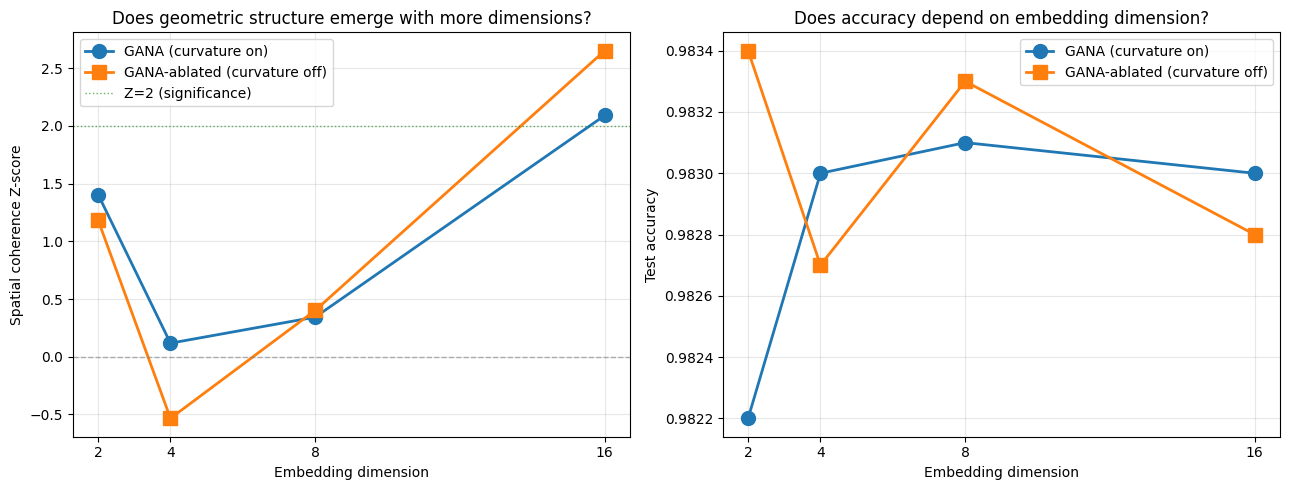

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for variant, marker, color in [('gana', 'o', 'C0'), ('gana_abl', 's', 'C1')]:
    zs = [results[f'ed{ed}_{variant}']['z_score'] for ed in EMBEDDING_DIMS]
    accs = [results[f'ed{ed}_{variant}']['acc'] for ed in EMBEDDING_DIMS]
    label = 'GANA (curvature on)' if variant == 'gana' else 'GANA-ablated (curvature off)'
    ax1.plot(EMBEDDING_DIMS, zs, marker=marker, color=color, markersize=10, linewidth=2, label=label)
    ax2.plot(EMBEDDING_DIMS, accs, marker=marker, color=color, markersize=10, linewidth=2, label=label)

ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.axhline(2, color='green', linestyle=':', linewidth=1, alpha=0.6, label='Z=2 (significance)')
ax1.set_xlabel('Embedding dimension'); ax1.set_ylabel('Spatial coherence Z-score')
ax1.set_title('Does geometric structure emerge with more dimensions?')
ax1.set_xticks(EMBEDDING_DIMS); ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel('Embedding dimension'); ax2.set_ylabel('Test accuracy')
ax2.set_title('Does accuracy depend on embedding dimension?')
ax2.set_xticks(EMBEDDING_DIMS); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_dim_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
with open('gana_dim_sweep_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

!zip dim_sweep_results.zip fig_dim_sweep.png gana_dim_sweep_results.json
from google.colab import files
files.download('dim_sweep_results.zip')

{
  "ed2_gana": {
    "ed": 2,
    "variant": "gana",
    "acc": 0.9822,
    "coherence": 0.1296875,
    "shuffle_mean": 0.1088046875,
    "shuffle_std": 0.014852117296318183,
    "z_score": 1.4060485803388467
  },
  "ed2_gana_abl": {
    "ed": 2,
    "variant": "gana_abl",
    "acc": 0.9834,
    "coherence": 0.140625,
    "shuffle_mean": 0.12153125,
    "shuffle_std": 0.016125696448138296,
    "z_score": 1.1840566527368708
  },
  "ed4_gana": {
    "ed": 4,
    "variant": "gana",
    "acc": 0.983,
    "coherence": 0.1234375,
    "shuffle_mean": 0.1216328125,
    "shuffle_std": 0.015313374895286594,
    "z_score": 0.11785033239486296
  },
  "ed4_gana_abl": {
    "ed": 4,
    "variant": "gana_abl",
    "acc": 0.9827,
    "coherence": 0.1203125,
    "shuffle_mean": 0.1289453125,
    "shuffle_std": 0.016178431264606396,
    "z_score": -0.5335997676664938
  },
  "ed8_gana": {
    "ed": 8,
    "variant": "gana",
    "acc": 0.9831,
    "coherence": 0.109375,
    "shuffle_mean": 0.104078124999

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to read the result

**Scenario A (best case for thesis):** GANA Z climbs with ed (1.3 at ed=2 -> 5+ at ed=16), ablation stays low, gap widens. Paper claim becomes: geometry is real at sufficient embedding dimension.

**Scenario B (interesting but weaker):** Both Z-scores climb together. The positions parameter helps but curvature isn't the cause. Paper claim shifts to: learnable positional parameters help.

**Scenario C (worst case but still publishable):** Both stay flat near zero. Geometric framing is wrong. Phase 1 wins come from extra parameters or a regularization effect. Honest paper: we proposed GANA, tested the geometric mechanism, falsified it, and identified the real cause.